In [28]:
import cv2
import numpy as np

REFERENCE_REAL_CM  = 5.4
REFERENCE_PIXELS   = 150
pixels_per_cm = REFERENCE_PIXELS / REFERENCE_REAL_CM

plant_img = cv2.imread(r'C:\Users\LalanaGurusinghe\OneDrive - Digital400 PVT LTD\Documents\AI\DAY 03\codes\plants\D10.png')
height , width = plant_img.shape[0:2]

plant_img = cv2.resize(plant_img, (int(width/2), int(height/2)))

hsv = cv2.cvtColor(plant_img, cv2.COLOR_BGR2HSV)

lower_color_limit = np.array([25,  40,  40])
upper_color_limit = np.array([95,  255, 255])

mask = cv2.inRange(hsv, lower_color_limit , upper_color_limit)

res = cv2.bitwise_and(plant_img,plant_img,mask=mask)

contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

print('no of Contours :',len(contours))

for cnt in contours:
    area = cv2.contourArea(cnt)
    print(area)
    
    if(area>1200.0):
        cv2.drawContours(plant_img, [cnt] , -1 , (0,255,255), 1)
        
        x,y,w,h = cv2.boundingRect(cnt)
        
        cv2.rectangle(plant_img,(x,y),(x+w , y+h) , (0,255,0) , 2)
        
        cv2.circle(plant_img,(int(x+w/2),y),7,(0,162,255), -1)
        cv2.circle(plant_img,(int(x+w/2),y+h),7,(0,162,255),-1)
        
        real_height_cm = round(h / pixels_per_cm, 2)
        
        cv2.putText(plant_img, "Height: " + str(real_height_cm) + "cm", (x+w, y+h), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
        
cv2.imshow('Plant Image',plant_img)
cv2.imshow('Mask',mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

no of Contours : 119
0.0
0.0
0.0
0.0
0.5
18.0
0.5
0.0
0.0
0.0
0.0
16.5
0.5
3.5
1.0
16.5
0.0
7.0
0.5
0.0
1.5
5.0
27.5
2.0
0.0
1.5
21.0
2.5
2.5
12.0
0.0
2.0
0.0
14.0
12.0
4.0
22.0
2.5
0.0
1.0
30.5
0.0
0.0
4.0
0.0
0.5
0.0
23.5
17.5
16.0
5.5
1.0
2.0
0.0
0.0
15.5
0.0
2.0
2.0
0.0
0.0
5.5
0.0
0.0
1.5
1.0
0.5
1.5
0.0
0.0
0.5
0.0
1.0
4.0
2.5
0.0
0.0
4.0
18.0
0.0
1.0
0.0
0.0
8.5
0.0
0.0
0.0
0.0
0.5
0.0
0.5
5.0
0.0
3.5
8.0
0.0
4.0
0.0
8.0
2.0
0.0
0.0
0.0
4.0
0.0
0.0
0.0
5.0
32.0
3.0
0.0
3.0
29.0
55.0
0.0
0.0
68.5
7.0
3264.5


# 🌱 Plant Height Measurement using OpenCV

---

## Project Overview

This project detects **green plant regions** in an image using **HSV color masking** and measures the **real-world height** of each detected plant in **centimeters** using a reference scale.

---

## Full Project Code

```python
import cv2
import numpy as np

REFERENCE_REAL_CM  = 5.4
REFERENCE_PIXELS   = 150
pixels_per_cm = REFERENCE_PIXELS / REFERENCE_REAL_CM

plant_img = cv2.imread(r'your image path (abs or relative paths)')
height , width = plant_img.shape[0:2]
plant_img = cv2.resize(plant_img, (int(width/2), int(height/2)))
hsv = cv2.cvtColor(plant_img, cv2.COLOR_BGR2HSV)
lower_color_limit = np.array([25,  40,  40])
upper_color_limit = np.array([95,  255, 255])
mask = cv2.inRange(hsv, lower_color_limit , upper_color_limit)
res = cv2.bitwise_and(plant_img,plant_img,mask=mask)
contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print('no of Contours :',len(contours))
for cnt in contours:
    area = cv2.contourArea(cnt)
    print(area)
    if(area>1200.0):
        cv2.drawContours(plant_img, [cnt] , -1 , (0,255,255), 1)
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(plant_img,(x,y),(x+w , y+h) , (0,255,0) , 2)
        cv2.circle(plant_img,(int(x+w/2),y),7,(0,162,255), -1)
        cv2.circle(plant_img,(int(x+w/2),y+h),7,(0,162,255),-1)
        real_height_cm = round(h / pixels_per_cm, 2)
        cv2.putText(plant_img, "Height: " + str(real_height_cm) + "cm", (x+w, y+h), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

cv2.imshow('Plant Image',plant_img)
cv2.imshow('Mask',mask)
cv2.waitKey(0)
cv2.destroyAllWindows()
```

---

## Step by Step Explanation

---

### STEP 1 — Reference Scale Setup

```python
REFERENCE_REAL_CM  = 5.4
REFERENCE_PIXELS   = 150
pixels_per_cm = REFERENCE_PIXELS / REFERENCE_REAL_CM
```

This is the **most important part** for getting real-world measurements.

The idea is simple — if we know that a **known object** (e.g. a credit card) measures:
- `5.4 cm` in real life
- `150 pixels` in the image

Then we can calculate how many pixels = 1 cm:

$$
\text{pixels per cm} = \frac{\text{Reference Pixels}}{\text{Reference Real CM}} = \frac{150}{5.4} = 27.78 \text{ px/cm}
$$

Later we use this to convert any pixel measurement to cm:

$$
\text{Real Height (cm)} = \frac{\text{Plant Height (pixels)}}{\text{pixels per cm}}
$$

| Variable | Value | Meaning |
|----------|-------|---------|
| `REFERENCE_REAL_CM` | 5.4 | Real size of reference object (credit card height) |
| `REFERENCE_PIXELS` | 150 | How many pixels that object takes in the image |
| `pixels_per_cm` | 27.78 | Scale factor for conversion |

---

### STEP 2 — Load the Image

```python
plant_img = cv2.imread(r'C:\Users\...\plants\D10.png')
```

- Loads the plant image in **BGR format** (Blue, Green, Red)
- This is OpenCV's default — NOT RGB

---

### STEP 3 — Resize the Image

```python
height, width = plant_img.shape[0:2]
plant_img = cv2.resize(plant_img, (int(width/2), int(height/2)))
```

- `shape[0:2]` returns `(height, width)` — ignoring the 3rd channel value
- Resize to **half the original size** for faster processing and better display
- `cv2.resize()` always takes `(width, height)` — not `(height, width)`

---

### STEP 4 — Convert BGR to HSV

```python
hsv = cv2.cvtColor(plant_img, cv2.COLOR_BGR2HSV)
```

Converts the image from BGR to **HSV color space**:

| Channel | Meaning | Range in OpenCV |
|---------|---------|-----------------|
| H (Hue) | The actual color | 0 – 179 |
| S (Saturation) | How vivid the color is | 0 – 255 |
| V (Value) | Brightness | 0 – 255 |

HSV is used instead of BGR because **detecting colors by range is much easier** in HSV. Green in BGR can have thousands of combinations, but in HSV it always falls in a small Hue range.

---

### STEP 5 — Define Color Range (Green Detection)

```python
lower_color_limit = np.array([25,  40,  40])
upper_color_limit = np.array([95, 255, 255])
```

Targets the **full range of plant/leaf greens**:

| Channel | Lower | Upper | What it captures |
|---------|-------|-------|-----------------|
| H | 25 | 95 | Yellow-green → pure green → dark green |
| S | 40 | 255 | Moderately vivid to fully vivid greens |
| V | 40 | 255 | Medium brightness to fully bright greens |

```
H value reference:
0──────25──────────────95──────────179
  red   yellow-green  dark-green   red
         ←── our range ───→
```

---

### STEP 6 — Create the Mask

```python
mask = cv2.inRange(hsv, lower_color_limit, upper_color_limit)
```

Scans every pixel and creates a **binary image**:

```
Pixel inside color range  →  255 (WHITE) ✅  — plant detected
Pixel outside color range →  0   (BLACK) ❌  — not a plant
```

Example:
```
HSV Image           Mask
🟢 🔴 🟢            ⬜ ⬛ ⬜
🔵 🟢 🟡    →       ⬛ ⬜ ⬛
🟢 🟢 🔴            ⬜ ⬜ ⬛
```

---

### STEP 7 — Apply Mask with Bitwise AND

```python
res = cv2.bitwise_and(plant_img, plant_img, mask=mask)
```

Applies the mask to the original image:

```
mask = 255 (white) → keep original pixel color  ✅
mask = 0   (black) → pixel becomes black (0,0,0) ❌
```

Result: Only the **green plant areas** are visible, everything else is black.

---

### STEP 8 — Find Contours

```python
contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print('no of Contours :', len(contours))
```

- `contours` → list of all detected boundaries in the white regions of the mask
- `hierarchy` → parent/child relationship between contours
- `RETR_TREE` → finds all contours including nested ones
- `CHAIN_APPROX_SIMPLE` → stores only corner points (saves memory)

---

### STEP 9 — Filter by Area and Draw Measurements

```python
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 1200.0:
```

Loops through every contour and **ignores small ones** (noise, dust, shadows).
Only contours with area greater than **1200 pixels** are processed.

---

#### Draw the Contour Outline

```python
cv2.drawContours(plant_img, [cnt], -1, (0, 255, 255), 1)
```
Draws the exact **boundary of the detected plant** in yellow.

---

#### Draw Bounding Rectangle

```python
x, y, w, h = cv2.boundingRect(cnt)
cv2.rectangle(plant_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
```

`cv2.boundingRect()` returns the smallest rectangle that fits around the contour:

```
(x, y) ──────────────────┐
  │                       │
  │     plant region      │  h (height in pixels)
  │                       │
  └──────────────────(x+w, y+h)
         w (width)
```

| Variable | Meaning |
|----------|---------|
| `x, y` | Top-left corner of the rectangle |
| `w` | Width of the rectangle in pixels |
| `h` | Height of the rectangle in pixels |

---

#### Draw Top and Bottom Circles

```python
cv2.circle(plant_img, (int(x+w/2), y),     7, (0, 162, 255), -1)  # top
cv2.circle(plant_img, (int(x+w/2), y+h),   7, (0, 162, 255), -1)  # bottom
```

Places **orange circles** at the top and bottom center of the bounding box — visually marking the start and end of the height measurement.

```
        ● ← top circle     (int(x+w/2), y)
        │
        │ ← height being measured
        │
        ● ← bottom circle  (int(x+w/2), y+h)
```

---

#### Convert Pixels to Real CM and Display

```python
real_height_cm = round(h / pixels_per_cm, 2)
cv2.putText(plant_img, "Height: " + str(real_height_cm) + "cm", (x+w, y+h), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
```

$$
\text{real\_height\_cm} = \frac{h}{\text{pixels\_per\_cm}} = \frac{h}{27.78}
$$

`round(..., 2)` keeps the result to **2 decimal places** (e.g. `12.34 cm`).

`cv2.putText()` parameters:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| image | `plant_img` | Draw on this image |
| text | `"Height: 12.34cm"` | Text to display |
| position | `(x+w, y+h)` | Bottom right of bounding box |
| font | `FONT_HERSHEY_SIMPLEX` | Clean simple font |
| scale | `1` | Font size |
| color | `(255,255,255)` | White |
| thickness | `2` | Bold text |

---

### STEP 10 — Display Results

```python
cv2.imshow('Plant Image', plant_img)
cv2.imshow('Mask', mask)
cv2.waitKey(0)
cv2.destroyAllWindows()
```

| Window | Shows |
|--------|-------|
| `Plant Image` | Original with contours, rectangles, circles, and height labels |
| `Mask` | Black and white — white = detected green plant areas |

---

## Full Pipeline Summary

```
D10.png (original plant image)
        ↓
    Resize to half
        ↓
    Convert BGR → HSV
        ↓
    inRange() → Binary Mask (white = green plant pixels)
        ↓
    bitwise_and() → Isolated green regions
        ↓
    findContours() → Detect boundaries of green blobs
        ↓
    Filter by area > 1200 → Remove noise
        ↓
    boundingRect() → Get x, y, w, h of each plant
        ↓
    h / pixels_per_cm → Convert to real cm
        ↓
    Draw contour + rectangle + circles + height label
        ↓
    Display result
```

---

## Visual Output Explanation

```
┌─────────────────────────────────┐
│                                 │
│        ● ← top circle           │
│        │                        │
│   ┌────┼────┐                   │
│   │  🌱🌱🌱 │ Height: 12.34cm   │
│   │  🌱🌱🌱 │                   │
│   └────┼────┘                   │
│        │                        │
│        ● ← bottom circle        │
│                                 │
└─────────────────────────────────┘
  Green = contour outline (yellow)
  Box   = bounding rectangle (green)
  Dots  = top/bottom markers (orange)
  Text  = real height in cm (white)
```

---

## How to Improve Accuracy

| Issue | Fix |
|-------|-----|
| Wrong cm values | Measure `REFERENCE_PIXELS` more carefully from your actual image |
| Missing dark leaves | Lower `V` in `lower_color_limit` from 40 to 20 |
| Picking up background | Raise `S` in `lower_color_limit` from 40 to 70 |
| Too many small contours | Raise area threshold from 1200 to 2000+ |
| Noisy mask | Add `cv2.morphologyEx()` to clean the mask before finding contours |

## Extra Knowledge

# `cv2.findContours()` Explained

---

## What it returns

```python
contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
```

Returns **two things**:
- `contours` → the actual outlines/boundaries found
- `hierarchy` → relationship between contours

---

## Parameter 1 — `mask` (input image)

```python
cv2.findContours(mask, ...)
```

- Must be a **binary image** (black and white only)
- White areas = where contours will be found
- Black areas = ignored
- That's why we pass the `mask` — it's already black and white

---

## Parameter 2 — `cv2.RETR_TREE` (retrieval mode)

Tells OpenCV **which contours to find**:

| Mode | What it finds |
|------|--------------|
| `RETR_EXTERNAL` | Only outermost contours |
| `RETR_LIST` | All contours, no hierarchy |
| `RETR_TREE` | All contours + full relationship tree |

`RETR_TREE` finds **everything** — outer borders, inner holes, nested shapes.

---

## Parameter 3 — `cv2.CHAIN_APPROX_SIMPLE` (approximation method)

Tells OpenCV **how to store the contour points**:

| Method | How it stores points |
|--------|---------------------|
| `CHAIN_APPROX_NONE` | Stores every single point |
| `CHAIN_APPROX_SIMPLE` | Stores only corner points |

```
CHAIN_APPROX_NONE        CHAIN_APPROX_SIMPLE
● ● ● ● ● ● ●            ●             ●
●           ●            
●           ●            
● ● ● ● ● ● ●            ●             ●

Stores 16 points         Stores only 4 corners
                         saves memory ✅
```

---

## What is `hierarchy`?

Describes the **relationship between contours** — which contour is inside which:

```
Outer shape ──── parent
    └── Inner hole ──── child
            └── Shape inside hole ──── grandchild
```

Each contour in hierarchy has 4 values:

```python
hierarchy[0][i] = [Next, Previous, FirstChild, Parent]
#                   ↓       ↓           ↓          ↓
#              next     previous    first child   parent
#              contour  contour     contour       contour
#              (-1 if none)
```

---

## What is `contours`?

A **list of arrays** — each array contains the points of one contour:

```python
print(len(contours))      # how many contours were found
print(contours[0])        # points of the first contour
print(len(contours[0]))   # how many points in first contour
```

Example output:

```
5                          ← 5 contours found
[[[120 200]]               ← x,y points of contour 0
 [[121 201]]
 [[122 202]]]
```

---

## Full Picture

```python
# mask looks like this (binary):
# ⬛ ⬛ ⬛ ⬛ ⬛
# ⬛ ⬜ ⬜ ⬜ ⬛
# ⬛ ⬜ ⬜ ⬜ ⬛
# ⬛ ⬜ ⬜ ⬜ ⬛
# ⬛ ⬛ ⬛ ⬛ ⬛

contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# contours[0] = the boundary points of the white rectangle
# hierarchy   = tells us there are no parent/child relationships
```

Simply put — `findContours()` looks at the white regions in your mask and **traces the boundary** of each white blob it finds.

---

## Full Working Example

```python
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── STEP 1: Load and resize image ──────────────────────────────────
plant_img = cv2.imread(r'C:\Users\LalanaGurusinghe\OneDrive - Digital400 PVT LTD\Documents\AI\DAY 03\codes\plants\D14.png')
height, width = plant_img.shape[0:2]
plant_img = cv2.resize(plant_img, (int(width/2), int(height/2)))

# ── STEP 2: Convert to HSV ─────────────────────────────────────────
hsv = cv2.cvtColor(plant_img, cv2.COLOR_BGR2HSV)

# ── STEP 3: Define color range and create mask ─────────────────────
lower_color_limit = np.array([28, 70, 133])
upper_color_limit = np.array([70, 255, 255])
mask = cv2.inRange(hsv, lower_color_limit, upper_color_limit)

# ── STEP 4: Find contours ──────────────────────────────────────────
contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

print("Total contours found:", len(contours))

# ── STEP 5: Draw contours ──────────────────────────────────────────
output = plant_img.copy()  # copy so we don't modify original
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)
# -1 means draw ALL contours in green with thickness 2

# ── STEP 6: Display using matplotlib (Jupyter friendly) ────────────
plant_rgb  = cv2.cvtColor(plant_img, cv2.COLOR_BGR2RGB)
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(plant_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(output_rgb)
plt.title('Contours Drawn')
plt.axis('off')

plt.show()
```

---

## Quick Summary

$$
\text{mask (binary image)} \xrightarrow{\text{findContours()}} \text{list of boundary points}
$$

| Parameter | Value Used | Meaning |
|-----------|-----------|---------|
| Input | `mask` | Binary image — white blobs to trace |
| Mode | `RETR_TREE` | Find all contours with hierarchy |
| Method | `CHAIN_APPROX_SIMPLE` | Store only corner points |
| Output 1 | `contours` | List of boundary point arrays |
| Output 2 | `hierarchy` | Parent/child relationships |

1 cm = 27.78 pixels
Plant Height : 11.2 cm
Plant Width  : 11.38 cm
─────────────────────────


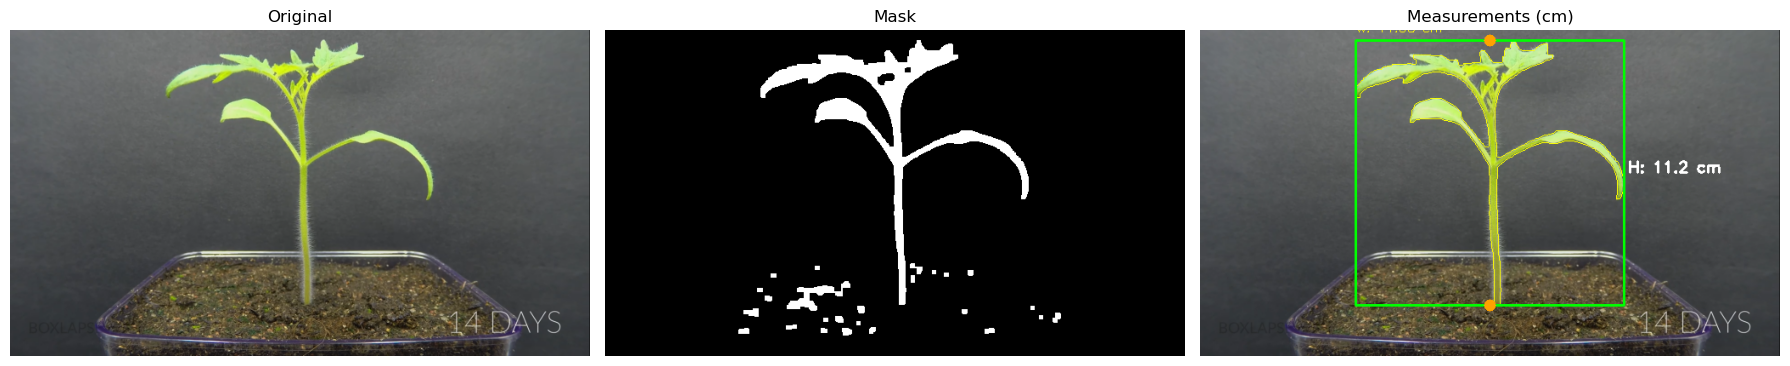

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── KNOWN reference object ─────────────────────────────────────────
# Credit card standard size = 8.56cm wide x 5.4cm tall
# Measure how many pixels the card takes in YOUR image
REFERENCE_REAL_CM  = 5.4    # credit card height = 5.4cm
REFERENCE_PIXELS   = 150    # measure this from your image manually

pixels_per_cm = REFERENCE_PIXELS / REFERENCE_REAL_CM
print(f"1 cm = {pixels_per_cm:.2f} pixels")

# ── Load and process ───────────────────────────────────────────────
plant_img = cv2.imread(r'C:\Users\LalanaGurusinghe\OneDrive - Digital400 PVT LTD\Documents\AI\DAY 03\codes\plants\D14.png')
height, width = plant_img.shape[0:2]
plant_img = cv2.resize(plant_img, (int(width/2), int(height/2)))
original  = plant_img.copy()

hsv = cv2.cvtColor(plant_img, cv2.COLOR_BGR2HSV)

lower_color_limit = np.array([25,  40,  40])
upper_color_limit = np.array([95, 255, 255])

mask = cv2.inRange(hsv, lower_color_limit, upper_color_limit)

kernel = np.ones((5,5), np.uint8)
mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 1200.0:
        x, y, w, h = cv2.boundingRect(cnt)

        # ── Convert to real measurements ───────────────────────────
        real_height_cm = round(h / pixels_per_cm, 2)
        real_width_cm  = round(w / pixels_per_cm, 2)

        print(f"Plant Height : {real_height_cm} cm")
        print(f"Plant Width  : {real_width_cm} cm")
        print("─────────────────────────")

        # ── Draw everything ────────────────────────────────────────
        cv2.drawContours(plant_img, [cnt], -1, (0, 255, 255), 1)
        cv2.rectangle(plant_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.circle(plant_img, (int(x+w/2), y),     7, (0, 162, 255), -1)
        cv2.circle(plant_img, (int(x+w/2), y+h),   7, (0, 162, 255), -1)

        # Show real height on image
        cv2.putText(plant_img,
                    f"H: {real_height_cm} cm",
                    (x + w + 5, y + int(h/2)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (255, 255, 255), 2)

        # Show real width on image
        cv2.putText(plant_img,
                    f"W: {real_width_cm} cm",
                    (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 255), 1)

# ── Display ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(original,   cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(plant_img,  cv2.COLOR_BGR2RGB))
axes[2].set_title('Measurements (cm)')
axes[2].axis('off')

plt.tight_layout()
plt.show()